# Evaluation des checkpoints sur crues completes

Ce notebook reprend `eval_checkpoints_fixed_hourly.ipynb`, mais sur les crues completes `0-0-80` stockees dans `results_data_30min`.

- memes crues test
- memes hydrogrammes `.liq`
- sortie limitee aux courbes moyenne ± ecart-type sur tout le rollout


In [1]:
import math
import os
import pickle
import sys

import dgl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.append(ROOT)

from python.create_dgl_dataset import TelemacDataset, TelemacDatasetWithQ
from python.CustomMeshGraphNet import MeshGraphNet
from modulus.launch.utils import load_checkpoint

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.dpi'] = 120

device


device(type='cuda')

In [2]:
!ls /work/m24046/m24046mrcr/dataset_x8_avec_ts/fullx8/

Group_1_peak_1200_Group_1_peak_1200_0_0-80_interpolated.pkl
Group_1_peak_1400_Group_1_peak_1400_0_0-80_interpolated.pkl
Group_1_peak_2000_Group_1_peak_2000_0_0-80_interpolated.pkl
Group_1_peak_2200_Group_1_peak_2200_0_0-80_interpolated.pkl
Group_1_peak_2400_Group_1_peak_2400_0_0-80_interpolated.pkl
Group_1_peak_2600_Group_1_peak_2600_0_0-80_interpolated.pkl
Group_2_peak_1000_Group_2_peak_1000_0_0-80_interpolated.pkl
Group_2_peak_1200_Group_2_peak_1200_0_0-80_interpolated.pkl
Group_2_peak_1600_Group_2_peak_1600_0_0-80_interpolated.pkl
Group_2_peak_3600_Group_2_peak_3600_0_0-80_interpolated.pkl
Group_3_peak_2200_Group_3_peak_2200_0_0-80_interpolated.pkl
Group_3_peak_2800_Group_3_peak_2800_0_0-80_interpolated.pkl
Group_3_peak_3400_Group_3_peak_3400_0_0-80_interpolated.pkl
Group_4_peak_1200_Group_4_peak_1200_0_0-80_interpolated.pkl
Group_4_peak_2000_Group_4_peak_2000_0_0-80_interpolated.pkl
Group_4_peak_3000_Group_4_peak_3000_0_0-80_interpolated.pkl
Mesh8_corrige.slf


In [3]:
# =====================
# Parametres utilisateur
# =====================
RAW_DYNAMIC_ROOT = '/work/m24046/m24046mrcr/dataset_x8_avec_ts/fullx8/'
MULTIMESH_GRAPH = '/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Multimesh_8_32.bin'
NORMAL_GRAPH = '/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Mesh8_base.bin'

HYDRO_ROOT = '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes'


# Meme selection de crues test que dans eval_checkpoints_fixed_hourly.ipynb
TEST_EVENTS = [
    'Group_1_peak_2600',
    'Group_2_peak_1000',
    'Group_2_peak_1200',
    'Group_2_peak_1600',
    'Group_4_peak_2000',
    'Group_1_peak_1200',
    'Group_1_peak_2400',
    'Group_3_peak_3400',
    'Group_1_peak_1400',
    'Group_1_peak_2000',
    'Group_1_peak_2200',
    'Group_2_peak_3600',
    'Group_3_peak_2200',
    "Group_3_peak_2800",
    "Group_4_peak_1200",
    "Group_4_peak_3000",
]


def build_dynamic_path(event_name):
    return os.path.join(RAW_DYNAMIC_ROOT, f'{event_name}_{event_name}_0_0-80_interpolated.pkl')


def build_hydro_path(event_name):
    return os.path.join(HYDRO_ROOT, f'generated_hydrographs_{event_name}.liq')


def graph_path_for_event(event_name, mesh):
    if mesh == 'normal':
        return NORMAL_GRAPH
    if mesh == 'multimesh':
        return MULTIMESH_GRAPH
    raise ValueError(f'Mesh inconnu: {mesh}')


DYNAMIC_DIR = [build_dynamic_path(event_name) for event_name in TEST_EVENTS]
HYDRO_DIR = [build_hydro_path(event_name) for event_name in TEST_EVENTS]

DT_SECONDS = 1800.0
REQUESTED_MAX_STEPS = 80
THRESHOLD_M = 0.1

METHODS = [
    {
        'name': 'Experiment 5',
        'ckpt_dir': '/work/m24046/m24046mrcr/paper/Experience8/Seed0/',
        'epoch': 900,
        'use_q_feature': True,
        'mesh': 'multimesh',
    },
    {
        'name': 'Experiment 6',
        'ckpt_dir': '/work/m24046/m24046mrcr/paper/Experience10/Seed0/',
        'epoch': 900,
        'use_q_feature': True,
        'mesh': 'multimesh',
    },
]

EXPERIENCE_COLORS = {
    'Experiment 1': '#1f77b4',
    'Experiment 2': '#ff7f0e',
    'Experiment 3': '#2ca02c',
    'Experiment 4': '#d62728',
    'Experiment 5': '#9467bd',
    'Experiment 6': '#8c564b',
}

RUN_ORDER = [f'Experiment {idx}@900' for idx in range(1, 7)]

NUM_EDGE_FEATURES = 3
NUM_OUTPUT_FEATURES = 3
MP_LAYERS = 10
DO_CONCAT_TRICK = True
NUM_PROCESSOR_CHECKPOINT_SEGMENTS = 0


In [4]:
def get_dynamic_length(file_path):
    with open(file_path, 'rb') as fp:
        return len(pickle.load(fp))


lengths_df = pd.DataFrame(
    [
        {
            'event': event_name,
            'dynamic_file': build_dynamic_path(event_name),
            'num_samples': get_dynamic_length(build_dynamic_path(event_name)),
        }
        for event_name in TEST_EVENTS
    ]
).sort_values(['num_samples', 'event']).reset_index(drop=True)

min_num_samples = int(lengths_df['num_samples'].min())
AVAILABLE_STEPS = max(1, min(REQUESTED_MAX_STEPS, min_num_samples))

if AVAILABLE_STEPS < REQUESTED_MAX_STEPS:
    print(
        f'Attention: au moins une crue contient seulement {min_num_samples} echantillons. '
        f'Le notebook evaluera donc {AVAILABLE_STEPS} pas de rollout communs.'
    )

HORIZONS_STEPS = list(range(1, AVAILABLE_STEPS + 1))
HORIZON_HOURS = np.asarray(HORIZONS_STEPS, dtype=float) * DT_SECONDS / 3600.0
SEQUENCE_LENGTH = AVAILABLE_STEPS
OVERLAP = 0

print(
    f'{len(TEST_EVENTS)} crues test | single unrolling | sequence_length={SEQUENCE_LENGTH} '
    f'| horizons={HORIZONS_STEPS[0]}..{HORIZONS_STEPS[-1]}'
)
lengths_df


16 crues test | single unrolling | sequence_length=80 | horizons=1..80


,event,dynamic_file,num_samples
0,Group_1_peak_1200,/work/m24046/m24046mrcr/dataset_x8_avec_ts/ful...,80
1,Group_1_peak_1400,/work/m24046/m24046mrcr/dataset_x8_avec_ts/ful...,80
2,Group_1_peak_2000,/work/m24046/m24046mrcr/dataset_x8_avec_ts/ful...,80
3,Group_1_peak_2200,/work/m24046/m24046mrcr/dataset_x8_avec_ts/ful...,80
4,Group_1_peak_2400,/work/m24046/m24046mrcr/dataset_x8_avec_ts/ful...,80
5,Group_1_peak_2600,/work/m24046/m24046mrcr/dataset_x8_avec_ts/ful...,80
6,Group_2_peak_1000,/work/m24046/m24046mrcr/dataset_x8_avec_ts/ful...,80
7,Group_2_peak_1200,/work/m24046/m24046mrcr/dataset_x8_avec_ts/ful...,80
8,Group_2_peak_1600,/work/m24046/m24046mrcr/dataset_x8_avec_ts/ful...,80
9,Group_2_peak_3600,/work/m24046/m24046mrcr/dataset_x8_avec_ts/ful...,80


In [5]:
# =====================
# Helpers evaluation
# =====================
def build_model(num_input_features):
    return MeshGraphNet(
        num_input_features,
        NUM_EDGE_FEATURES,
        NUM_OUTPUT_FEATURES,
        processor_size=MP_LAYERS,
        hidden_dim_processor=64,
        hidden_dim_node_encoder=64,
        hidden_dim_edge_encoder=64,
        hidden_dim_node_decoder=64,
        do_concat_trick=DO_CONCAT_TRICK,
        num_processor_checkpoint_segments=NUM_PROCESSOR_CHECKPOINT_SEGMENTS,
    )


def load_model_checkpoint(model, ckpt_dir, epoch):
    load_checkpoint(ckpt_dir, models=model, device=device, epoch=epoch)
    model.to(device)
    model.eval()
    return model


def build_event_dataset(event_name, ckpt_dir, use_q_feature, mesh, sequence_length, overlap=0, split='test'):
    data_dir = graph_path_for_event(event_name, mesh)
    dynamic_file = build_dynamic_path(event_name)

    if use_q_feature:
        hydro_file = build_hydro_path(event_name)
        return TelemacDatasetWithQ(
            name=f'eval_{event_name}',
            data_dir=data_dir,
            dynamic_data_files=[dynamic_file],
            hydro_data_files=[hydro_file],
            split=split,
            ckpt_path=ckpt_dir,
            normalize=True,
            sequence_length=sequence_length,
            overlap=overlap,
            dt_seconds=DT_SECONDS,
        )

    return TelemacDataset(
        name=f'eval_{event_name}',
        data_dir=data_dir,
        dynamic_data_files=[dynamic_file],
        split=split,
        ckpt_path=ckpt_dir,
        normalize=True,
        sequence_length=sequence_length,
        overlap=overlap,
    )


def _denorm(xn, mean, std):
    return xn * std + mean


def _renorm(x, mean, std):
    return (x - mean) / (std + 1e-12)


def csi_from_binary(pred_mask, gt_mask):
    tp = np.logical_and(pred_mask, gt_mask).sum()
    fp = np.logical_and(pred_mask, ~gt_mask).sum()
    fn = np.logical_and(~pred_mask, gt_mask).sum()
    denom = tp + fp + fn
    return float(tp / denom) if denom > 0 else math.nan


def evaluate_single_event(model, ds, horizons_steps, use_q_feature, threshold=0.1):
    if len(ds) == 0:
        raise ValueError('Dataset vide pour cet evenement.')
    if len(ds) > 1:
        print(f'Attention: {len(ds)} sequences trouvees, seule la premiere est utilisee pour garder un seul unrolling.')

    graphs = ds[0]
    max_h = max(horizons_steps)
    if len(graphs) < max_h:
        raise ValueError(
            f'Sequence trop courte: len(graphs)={len(graphs)} alors que max_h={max_h}.'
        )

    stats = ds.node_stats
    dyn_start = ds.base_graph.ndata['static'].shape[1]
    dyn_len = 4 if use_q_feature else 3

    mx = torch.tensor([stats['h'].item(), stats['u'].item(), stats['v'].item()], device=device)
    sx = torch.tensor([stats['h_std'].item(), stats['u_std'].item(), stats['v_std'].item()], device=device)
    dy_mean = torch.tensor(
        [stats['delta_h'].item(), stats['delta_u'].item(), stats['delta_v'].item()],
        device=device,
    )
    dy_std = torch.tensor(
        [stats['delta_h_std'].item(), stats['delta_u_std'].item(), stats['delta_v_std'].item()],
        device=device,
    )

    q_signature = torch.tensor([0, 0, 1, 0], device=device)
    h_signature = torch.tensor([0, 1, 0, 0], device=device)
    step_to_index = {step: idx for idx, step in enumerate(horizons_steps)}

    mse = np.full((len(horizons_steps), 3), np.nan, dtype=float)
    l1 = np.full((len(horizons_steps), 3), np.nan, dtype=float)
    csi = np.full(len(horizons_steps), np.nan, dtype=float)

    g = graphs[0].to(device)
    static_part = g.ndata['x'][:, :dyn_start]
    xn_t_full = g.ndata['x'][:, dyn_start:dyn_start + dyn_len]

    onehot = static_part[:, :4]
    q_mask = (onehot == q_signature).all(dim=1)
    h_mask = (onehot == h_signature).all(dim=1)

    for t in range(max_h):
        with torch.no_grad():
            y_pred_n = model(g.ndata['x'], g.edata['x'], g)

        xn_t = xn_t_full[:, :3]
        x_t = _denorm(xn_t, mx, sx)
        y_pred = _denorm(y_pred_n, dy_mean, dy_std)
        x_t1 = x_t + y_pred

        # Le y du sample courant permet de reconstruire x_{t+1} et donc de scorer aussi le dernier pas disponible.
        g_ref_t = graphs[t]
        x_ref_full_n = g_ref_t.ndata['x'][:, dyn_start:dyn_start + dyn_len].to(device)
        x_ref_t_n = x_ref_full_n[:, :3]
        x_ref_t = _denorm(x_ref_t_n, mx, sx)
        y_gt_n = g_ref_t.ndata['y'][:, :3].to(device)
        y_gt = _denorm(y_gt_n, dy_mean, dy_std)
        x_gt = x_ref_t + y_gt

        x_t1[q_mask] = x_gt[q_mask]
        x_t1[h_mask, 0:1] = x_gt[h_mask, 0:1]

        step = t + 1
        if step in step_to_index:
            step_idx = step_to_index[step]
            mse[step_idx] = torch.mean((x_t1 - x_gt) ** 2, dim=0).detach().cpu().numpy()
            l1[step_idx] = torch.mean(torch.abs(x_t1 - x_gt), dim=0).detach().cpu().numpy()
            h_pred = x_t1[:, 0].detach().cpu().numpy()
            h_gt = x_gt[:, 0].detach().cpu().numpy()
            csi[step_idx] = csi_from_binary(h_pred >= threshold, h_gt >= threshold)

        xn_t1 = _renorm(x_t1, mx, sx)
        if use_q_feature:
            if t + 1 < len(graphs):
                q_t1_n = graphs[t + 1].ndata['x'][:, dyn_start + 3:dyn_start + 4].to(device)
            else:
                q_t1_n = xn_t_full[:, 3:4]
            xn_t_full = torch.cat([xn_t1, q_t1_n], dim=1)
        else:
            xn_t_full = xn_t1

        g = g.clone()
        g.ndata['x'] = torch.cat([static_part, xn_t_full], dim=1)

    return {
        'mse': mse,
        'l1': l1,
        'csi': csi,
    }


def aggregate_event_metrics(event_metrics):
    if not event_metrics:
        raise ValueError('Aucune metrique evenement a agreger.')

    mse_stack = np.stack([payload['mse'] for payload in event_metrics.values()], axis=0)
    l1_stack = np.stack([payload['l1'] for payload in event_metrics.values()], axis=0)
    csi_stack = np.stack([payload['csi'] for payload in event_metrics.values()], axis=0)

    return {
        'n_events': len(event_metrics),
        'mse_mean': np.nanmean(mse_stack, axis=0),
        'mse_std': np.nanstd(mse_stack, axis=0),
        'l1_mean': np.nanmean(l1_stack, axis=0),
        'l1_std': np.nanstd(l1_stack, axis=0),
        'csi_mean': np.nanmean(csi_stack, axis=0),
        'csi_std': np.nanstd(csi_stack, axis=0),
    }


def evaluate_fixed_methods(methods, events, horizons_steps, threshold=0.1):
    fixed_metrics = {}

    for method in methods:
        name = method['name']
        ckpt_dir = method['ckpt_dir']
        epoch = method['epoch']
        use_q_feature = method.get('use_q_feature', True)
        mesh = method.get('mesh', 'normal')
        run_name = f'{name}@{epoch}'

        print(f'Evaluation de {run_name}...')
        event_metrics = {}
        model = None

        for event_name in events:
            print(f'  - {event_name}')
            ds = build_event_dataset(
                event_name=event_name,
                ckpt_dir=ckpt_dir,
                use_q_feature=use_q_feature,
                mesh=mesh,
                sequence_length=SEQUENCE_LENGTH,
                overlap=OVERLAP,
                split='test',
            )

            if model is None:
                num_input_features = ds.base_graph.ndata['static'].shape[1] + (4 if use_q_feature else 3)
                model = build_model(num_input_features)
                load_model_checkpoint(model, ckpt_dir, epoch=epoch)

            event_metrics[event_name] = evaluate_single_event(
                model,
                ds,
                horizons_steps=horizons_steps,
                use_q_feature=use_q_feature,
                threshold=threshold,
            )

        fixed_metrics[run_name] = {
            'method': name,
            'mesh': mesh,
            'epoch': epoch,
            'ckpt_dir': ckpt_dir,
            'steps': np.asarray(horizons_steps, dtype=int),
            'hours': np.asarray(horizons_steps, dtype=float) * DT_SECONDS / 3600.0,
            'summary': aggregate_event_metrics(event_metrics),
            'per_event': event_metrics,
        }

        if device.type == 'cuda':
            torch.cuda.empty_cache()

    return fixed_metrics


def build_summary_frame(fixed_metrics):
    rows = []

    for run_name, payload in fixed_metrics.items():
        summary = payload['summary']
        steps = payload['steps']
        hours = payload['hours']

        for idx, (step, hour) in enumerate(zip(steps, hours)):
            rows.append(
                {
                    'run_name': run_name,
                    'method': payload['method'],
                    'mesh': payload['mesh'],
                    'epoch': payload['epoch'],
                    'n_events': summary['n_events'],
                    'horizon_step': int(step),
                    'horizon_hours': float(hour),
                    'csi_mean': float(summary['csi_mean'][idx]),
                    'csi_std': float(summary['csi_std'][idx]),
                    'l1_h_mean': float(summary['l1_mean'][idx, 0]),
                    'l1_h_std': float(summary['l1_std'][idx, 0]),
                    'l1_u_mean': float(summary['l1_mean'][idx, 1]),
                    'l1_u_std': float(summary['l1_std'][idx, 1]),
                    'l1_v_mean': float(summary['l1_mean'][idx, 2]),
                    'l1_v_std': float(summary['l1_std'][idx, 2]),
                    'mse_h_mean': float(summary['mse_mean'][idx, 0]),
                    'mse_h_std': float(summary['mse_std'][idx, 0]),
                    'mse_u_mean': float(summary['mse_mean'][idx, 1]),
                    'mse_u_std': float(summary['mse_std'][idx, 1]),
                    'mse_v_mean': float(summary['mse_mean'][idx, 2]),
                    'mse_v_std': float(summary['mse_std'][idx, 2]),
                }
            )

    return pd.DataFrame(rows).sort_values(['method', 'horizon_step']).reset_index(drop=True)


In [6]:
fixed_metrics = evaluate_fixed_methods(
    METHODS,
    events=TEST_EVENTS,
    horizons_steps=HORIZONS_STEPS,
    threshold=THRESHOLD_M,
)

summary_df = build_summary_frame(fixed_metrics)
summary_df.groupby('method', as_index=False)['n_events'].max()


Evaluation de Experiment 5@900...
  - Group_1_peak_2600
Loading normalization statistics...


[21:22:09 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[21:22:09 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.900.pt to device cuda


  - Group_2_peak_1000
Loading normalization statistics...
  - Group_2_peak_1200
Loading normalization statistics...
  - Group_2_peak_1600
Loading normalization statistics...
  - Group_4_peak_2000
Loading normalization statistics...
  - Group_1_peak_1200
Loading normalization statistics...
  - Group_1_peak_2400
Loading normalization statistics...
  - Group_3_peak_3400
Loading normalization statistics...
  - Group_1_peak_1400
Loading normalization statistics...
  - Group_1_peak_2000
Loading normalization statistics...
  - Group_1_peak_2200
Loading normalization statistics...
  - Group_2_peak_3600
Loading normalization statistics...
  - Group_3_peak_2200
Loading normalization statistics...
  - Group_3_peak_2800
Loading normalization statistics...
  - Group_4_peak_1200
Loading normalization statistics...
  - Group_4_peak_3000
Loading normalization statistics...
Evaluation de Experiment 6@900...
  - Group_1_peak_2600
Loading normalization statistics...


[21:22:33 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience10/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[21:22:34 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience10/Seed0/checkpoint.0.900.pt to device cuda


  - Group_2_peak_1000
Loading normalization statistics...
  - Group_2_peak_1200
Loading normalization statistics...
  - Group_2_peak_1600
Loading normalization statistics...
  - Group_4_peak_2000
Loading normalization statistics...
  - Group_1_peak_1200
Loading normalization statistics...
  - Group_1_peak_2400
Loading normalization statistics...
  - Group_3_peak_3400
Loading normalization statistics...
  - Group_1_peak_1400
Loading normalization statistics...
  - Group_1_peak_2000
Loading normalization statistics...
  - Group_1_peak_2200
Loading normalization statistics...
  - Group_2_peak_3600
Loading normalization statistics...
  - Group_3_peak_2200
Loading normalization statistics...
  - Group_3_peak_2800
Loading normalization statistics...
  - Group_4_peak_1200
Loading normalization statistics...
  - Group_4_peak_3000
Loading normalization statistics...


,method,n_events
0,Experiment 5,16
1,Experiment 6,16


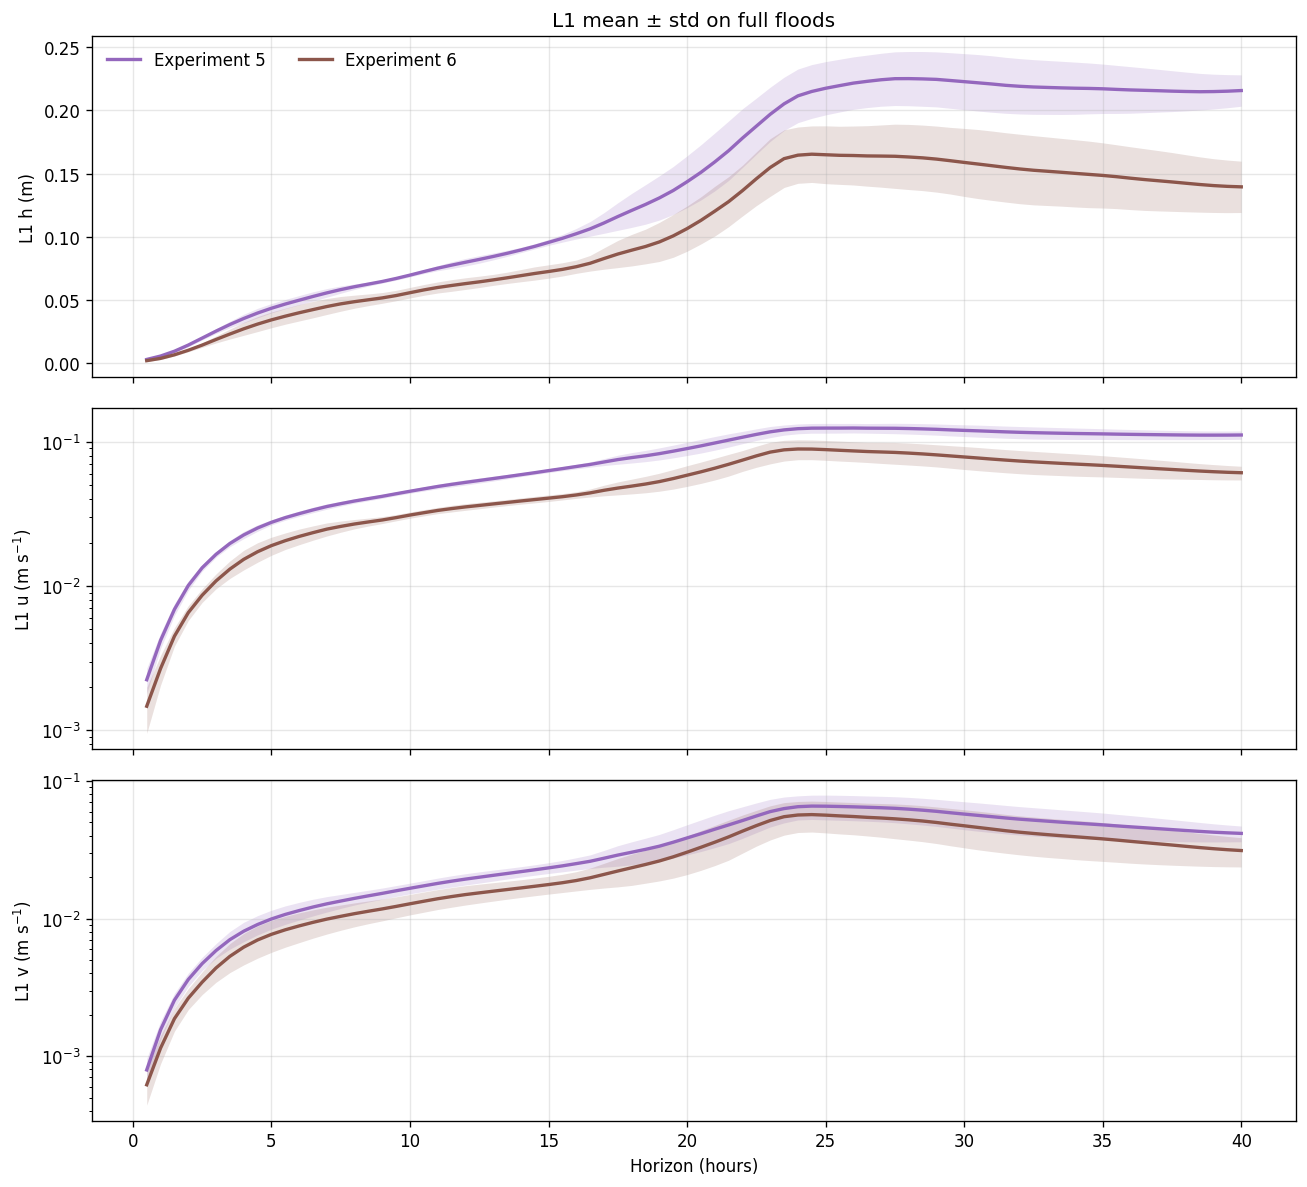

In [12]:
# =====================
# Traces mean ± std
# =====================
def _style_for_experience(label):
    return {
        'color': EXPERIENCE_COLORS[label],
        'linewidth': 2.0,
    }


def _extract_mean_std(payload, metric_name, comp_idx=None):
    mean_vals = np.asarray(payload['summary'][f'{metric_name}_mean'], dtype=float)
    std_vals = np.asarray(payload['summary'][f'{metric_name}_std'], dtype=float)

    if comp_idx is not None:
        mean_vals = mean_vals[:, comp_idx]
        std_vals = std_vals[:, comp_idx]

    return mean_vals.copy(), std_vals.copy()


def plot_csi_with_std(fixed_metrics, run_order=None):
    if not fixed_metrics:
        print('Pas de resultats')
        return

    run_order = run_order or list(fixed_metrics.keys())
    fig, ax = plt.subplots(figsize=(11, 4.5))

    for run_name in run_order:
        if run_name not in fixed_metrics:
            continue

        payload = fixed_metrics[run_name]
        mean_vals, std_vals = _extract_mean_std(payload, 'csi')
        lower = np.clip(mean_vals - std_vals, 0.0, 1.0)
        upper = np.clip(mean_vals + std_vals, 0.0, 1.0)
        style = _style_for_experience(payload['method'])

        ax.plot(payload['hours'], mean_vals, label=payload['method'], **style)
        ax.fill_between(payload['hours'], lower, upper, color=style['color'], alpha=0.18, linewidth=0)

    ax.set_title(f'CSI mean ± std sur crues completes (threshold={THRESHOLD_M:.3f} m)')
    ax.set_xlabel('Horizon (hours)')
    ax.set_ylabel('CSI')
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()


def plot_l1_components_with_std(fixed_metrics, run_order=None):
    if not fixed_metrics:
        print('Pas de resultats')
        return

    run_order = run_order or list(fixed_metrics.keys())
    rows = [
        (0, False, 'L1 h (m)'),
        (1, True, r'L1 u (m s$^{-1}$)'),
        (2, True, r'L1 v (m s$^{-1}$)'),
    ]

    fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

    for ax, (comp_idx, use_log, ylabel) in zip(axes, rows):
        for run_name in run_order:
            if run_name not in fixed_metrics:
                continue

            payload = fixed_metrics[run_name]
            mean_vals, std_vals = _extract_mean_std(payload, 'l1', comp_idx=comp_idx)
            lower = mean_vals - std_vals
            upper = mean_vals + std_vals

            if use_log:
                mean_vals[mean_vals <= 0.0] = np.nan
                lower[lower <= 0.0] = np.nan

            style = _style_for_experience(payload['method'])
            ax.plot(payload['hours'], mean_vals, label=payload['method'], **style)
            ax.fill_between(payload['hours'], lower, upper, color=style['color'], alpha=0.18, linewidth=0)

        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        if use_log:
            ax.set_yscale('log')

    axes[0].set_title('L1 mean ± std on full floods')
    axes[-1].set_xlabel('Horizon (hours)')
    axes[0].legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()


#plot_csi_with_std(fixed_metrics, run_order=RUN_ORDER)
plot_l1_components_with_std(fixed_metrics, run_order=RUN_ORDER)


In [10]:
summary_df.to_csv("full.csv")


Loading normalization statistics...


[21:54:14 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience8/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[21:54:14 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience8/Seed0/checkpoint.0.900.pt to device cuda


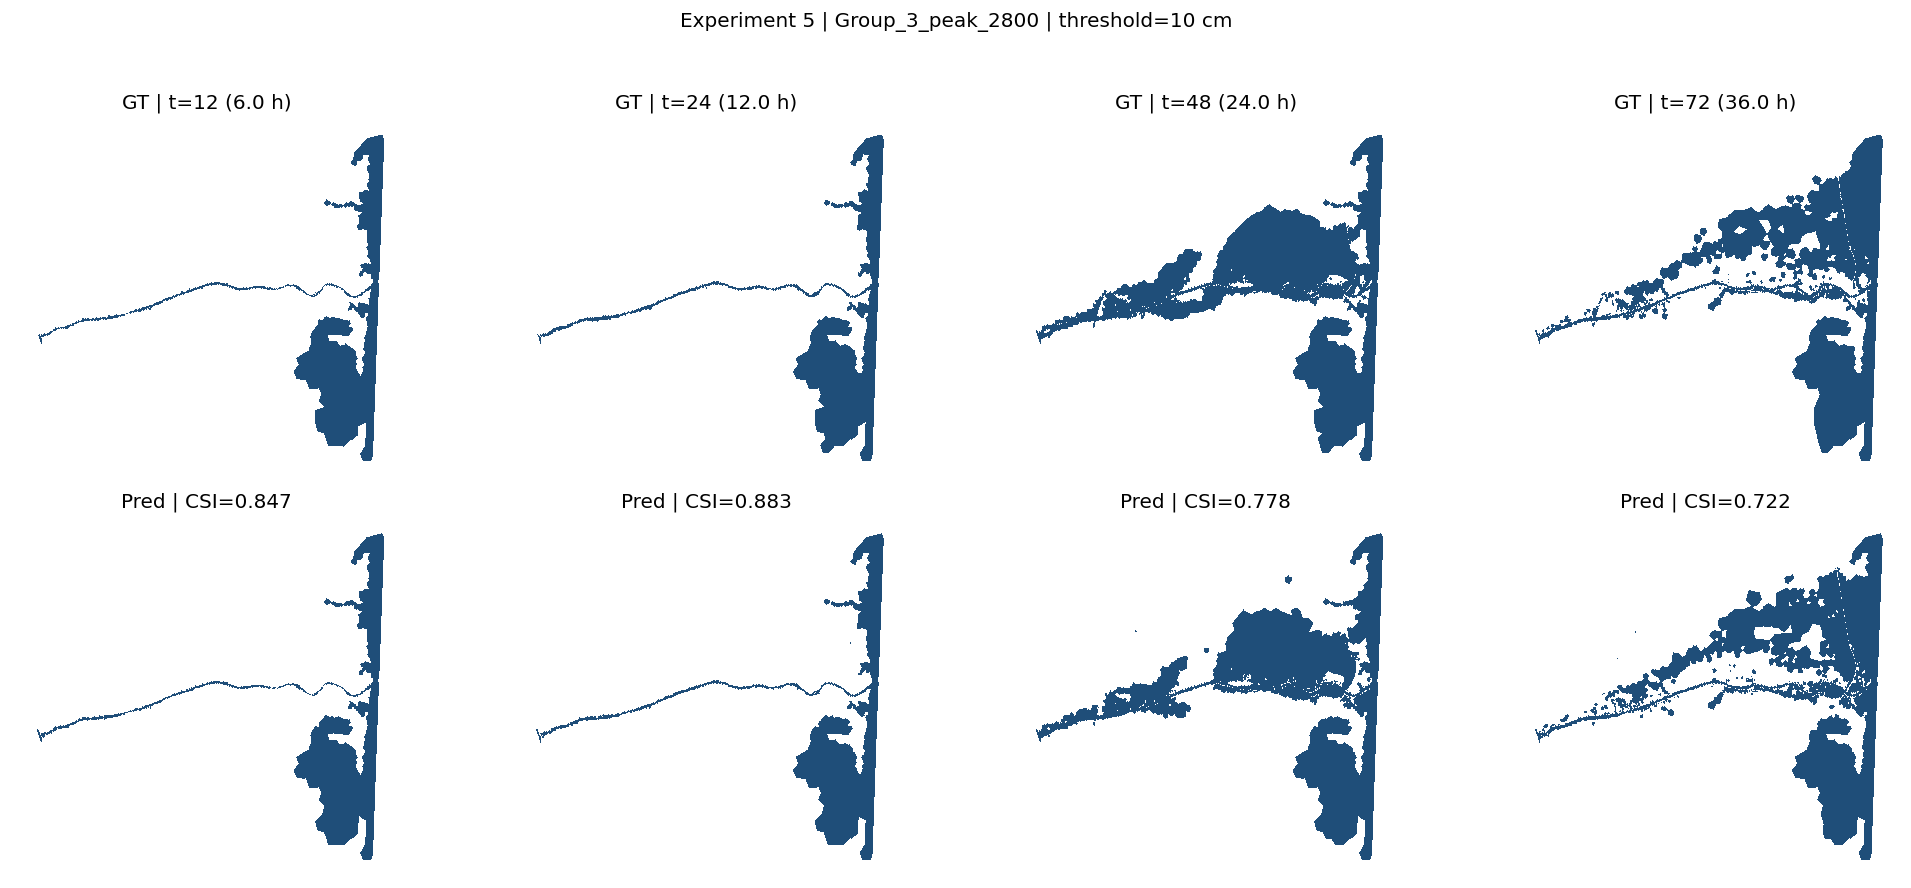

Loading normalization statistics...


[21:54:18 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience10/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[21:54:18 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience10/Seed0/checkpoint.0.900.pt to device cuda


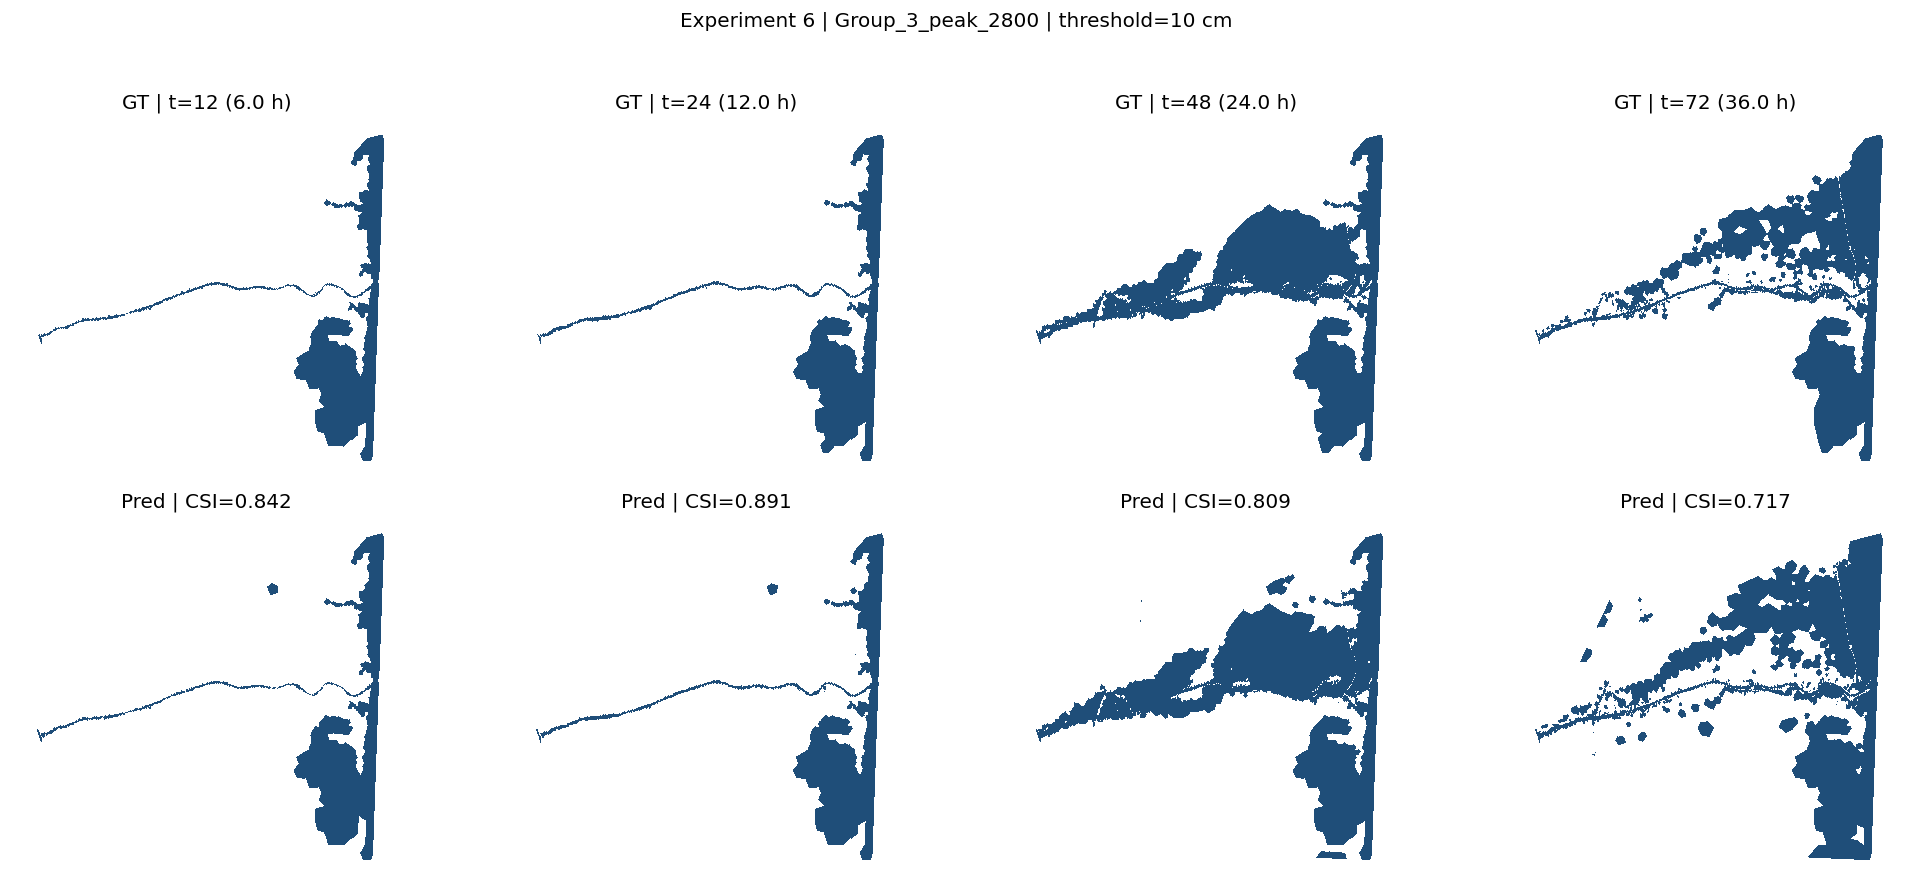

In [14]:
import matplotlib.tri as mtri
from matplotlib.colors import ListedColormap
from python.python_code.data_manip.extraction.telemac_file import TelemacFile

# =====================
# Cartes binaires sur le maillage x8
# =====================
QUAL_EVENT_INDEX = -3
QUAL_SEQUENCE_INDEX = 0   # avec le single unrolling, laisse 0
QUAL_THRESHOLD_M = THRESHOLD_M
QUAL_SELECTED_EXPERIENCES = ["Experiment 5", "Experiment 6"]
QUAL_HOURS = [ 6, 12,24,36]   # heures a afficher

# adapte ce chemin si besoin
X8_MESH_PATH = "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Mesh8_corrige.slf"

_BINARY_MODEL_CACHE = {}
_TRI_CACHE = {}


def hours_to_steps(hours):
    return int(round(hours * 3600.0 / DT_SECONDS))


def get_method_config(method_name):
    for method in METHODS:
        run_name = f"{method['name']}@{method.get('epoch')}"
        if method["name"] == method_name or run_name == method_name:
            return method
    available = ", ".join(method["name"] for method in METHODS)
    raise KeyError(f"Methode inconnue: {method_name}. Disponibles: {available}")


def get_cached_model(ds, method, use_q_feature):
    key = (
        method["ckpt_dir"],
        method["epoch"],
        use_q_feature,
        method.get("mesh", "normal"),
    )
    if key not in _BINARY_MODEL_CACHE:
        expected_input_features = ds.base_graph.ndata["static"].shape[1] + (4 if use_q_feature else 3)
        model = build_model(expected_input_features)
        load_model_checkpoint(model, method["ckpt_dir"], method["epoch"])
        _BINARY_MODEL_CACHE[key] = model
    return _BINARY_MODEL_CACHE[key]


def get_tri2d(mesh_path):
    if mesh_path not in _TRI_CACHE:
        mesh = TelemacFile(mesh_path)
        x = np.asarray(mesh.meshx[:mesh.npoin2], dtype=np.float64)
        y = np.asarray(mesh.meshy[:mesh.npoin2], dtype=np.float64)

        if hasattr(mesh, "ikle2") and mesh.ikle2 is not None:
            triangles = np.asarray(mesh.ikle2, dtype=np.int64)
            if triangles.min() == 1:
                triangles = triangles - 1
        else:
            triangles = np.asarray(mesh.tri.triangles, dtype=np.int64)

        _TRI_CACHE[mesh_path] = mtri.Triangulation(x, y, triangles)
    return _TRI_CACHE[mesh_path]


def node_binary_to_face_binary(triangles, node_binary):
    return node_binary[triangles].max(axis=1).astype(float)


def rollout_binary_maps_x8_for_method(
    method,
    event_index,
    sequence_index,
    horizon_steps,
    threshold,
):
    if event_index >= len(TEST_EVENTS):
        raise IndexError(f"event_index={event_index} hors bornes pour {len(TEST_EVENTS)} evenements")

    horizon_steps = sorted(set(int(s) for s in horizon_steps))
    if min(horizon_steps) < 1:
        raise ValueError("Tous les horizons doivent etre >= 1")

    event_name = TEST_EVENTS[event_index]
    use_q_feature = method.get("use_q_feature", False)
    mesh = method.get("mesh", "normal")

    ds = build_event_dataset(
        event_name=event_name,
        ckpt_dir=method["ckpt_dir"],
        use_q_feature=use_q_feature,
        mesh=mesh,
        sequence_length=SEQUENCE_LENGTH,
        overlap=OVERLAP,
        split="test",
    )

    if sequence_index >= len(ds):
        raise IndexError(f"sequence_index={sequence_index} hors bornes pour len(ds)={len(ds)}")

    graphs = ds[sequence_index]
    max_h = max(horizon_steps)
    if max_h > len(graphs):
        raise ValueError(f"max horizon={max_h} > len(graphs)={len(graphs)}")

    model = get_cached_model(ds, method, use_q_feature)

    stats = ds.node_stats
    dyn_start = ds.base_graph.ndata["static"].shape[1]
    dyn_len = 4 if use_q_feature else 3

    mx = torch.tensor([stats["h"].item(), stats["u"].item(), stats["v"].item()], device=device)
    sx = torch.tensor([stats["h_std"].item(), stats["u_std"].item(), stats["v_std"].item()], device=device)
    dy_mean = torch.tensor([stats["delta_h"].item(), stats["delta_u"].item(), stats["delta_v"].item()], device=device)
    dy_std = torch.tensor([stats["delta_h_std"].item(), stats["delta_u_std"].item(), stats["delta_v_std"].item()], device=device)

    g = graphs[0].to(device)
    static_part = g.ndata["x"][:, :dyn_start]
    xn_t_full = g.ndata["x"][:, dyn_start:dyn_start + dyn_len]

    onehot = static_part[:, :4]
    q_mask = (onehot == torch.tensor([0, 0, 1, 0], device=device)).all(dim=1)
    h_mask = (onehot == torch.tensor([0, 1, 0, 0], device=device)).all(dim=1)

    captured = {}

    for t in range(max_h):
        with torch.no_grad():
            y_pred_n = model(g.ndata["x"], g.edata["x"], g)

        xn_t = xn_t_full[:, :3]
        x_t = _denorm(xn_t, mx, sx)
        y_pred = _denorm(y_pred_n, dy_mean, dy_std)
        x_t1 = x_t + y_pred

        # verite terrain au pas t+1 via le y du sample courant
        g_ref_t = graphs[t]
        x_ref_full_n = g_ref_t.ndata["x"][:, dyn_start:dyn_start + dyn_len].to(device)
        x_ref_t_n = x_ref_full_n[:, :3]
        x_ref_t = _denorm(x_ref_t_n, mx, sx)
        y_gt_n = g_ref_t.ndata["y"][:, :3].to(device)
        y_gt = _denorm(y_gt_n, dy_mean, dy_std)
        x_gt = x_ref_t + y_gt

        x_t1[q_mask] = x_gt[q_mask]
        x_t1[h_mask, 0:1] = x_gt[h_mask, 0:1]

        step = t + 1
        if step in horizon_steps:
            h_pred = x_t1[:, 0].detach().cpu().numpy()
            h_gt = x_gt[:, 0].detach().cpu().numpy()

            pred_binary = h_pred >= threshold
            gt_binary = h_gt >= threshold
            csi = csi_from_binary(pred_binary, gt_binary)

            captured[step] = {
                "prediction_binary_nodes": pred_binary,
                "reference_binary_nodes": gt_binary,
                "csi": csi,
            }

        if step < max_h:
            xn_t1 = _renorm(x_t1, mx, sx)
            if use_q_feature:
                if t + 1 < len(graphs):
                    q_t1_n = graphs[t + 1].ndata["x"][:, dyn_start + 3:dyn_start + 4].to(device)
                else:
                    q_t1_n = xn_t_full[:, 3:4]
                xn_t_full = torch.cat([xn_t1, q_t1_n], dim=1)
            else:
                xn_t_full = xn_t1

            g = g.clone()
            g.ndata["x"] = torch.cat([static_part, xn_t_full], dim=1)

    return {
        "event_name": event_name,
        "payloads": captured,
    }


def plot_binary_maps_x8(
    selected_experiences,
    event_index=QUAL_EVENT_INDEX,
    sequence_index=QUAL_SEQUENCE_INDEX,
    hours_list=QUAL_HOURS,
    threshold=QUAL_THRESHOLD_M,
    mesh_path=X8_MESH_PATH,
):
    if len(selected_experiences) == 0:
        raise ValueError("Aucune experience selectionnee")

    horizon_steps = [hours_to_steps(h) for h in hours_list]
    tri = get_tri2d(mesh_path)
    cmap = ListedColormap(["white", "#1f4e79"])

    for method_name in selected_experiences:
        method = get_method_config(method_name)
        result = rollout_binary_maps_x8_for_method(
            method,
            event_index=event_index,
            sequence_index=sequence_index,
            horizon_steps=horizon_steps,
            threshold=threshold,
        )

        available_steps = [s for s in horizon_steps if s in result["payloads"]]
        ncols = len(available_steps)
        fig, axes = plt.subplots(2, ncols, figsize=(4.2 * ncols, 7.5), squeeze=False)

        for col, step in enumerate(available_steps):
            payload = result["payloads"][step]

            pred_face = node_binary_to_face_binary(tri.triangles, payload["prediction_binary_nodes"])
            gt_face = node_binary_to_face_binary(tri.triangles, payload["reference_binary_nodes"])

            ax = axes[0, col]
            ax.tripcolor(tri, facecolors=gt_face, shading="flat", cmap=cmap, vmin=0, vmax=1)
            ax.set_title(f"GT | t={step} ({step * DT_SECONDS / 3600.0:.1f} h)")
            ax.set_aspect("equal")
            ax.set_axis_off()

            ax = axes[1, col]
            ax.tripcolor(tri, facecolors=pred_face, shading="flat", cmap=cmap, vmin=0, vmax=1)
            ax.set_title(f"Pred | CSI={payload['csi']:.3f}")
            ax.set_aspect("equal")
            ax.set_axis_off()

        fig.suptitle(
            f"{method['name']} | {result['event_name']} | threshold={100 * threshold:.0f} cm",
            y=0.98,
        )
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


plot_binary_maps_x8(
    QUAL_SELECTED_EXPERIENCES,
    event_index=QUAL_EVENT_INDEX,
    sequence_index=QUAL_SEQUENCE_INDEX,
    hours_list=QUAL_HOURS,
    threshold=QUAL_THRESHOLD_M,
)

